In [12]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_moons

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.layers import Dropout
from keras.optimizers import Adam
from keras.regularizers import l1, l2

In [2]:
X, y = make_moons(100, noise=0.25,random_state=0)

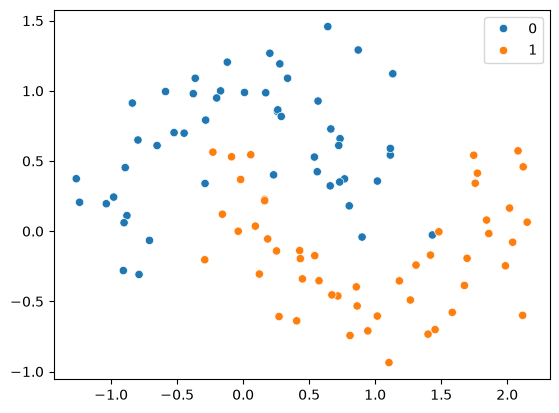

In [3]:
sns.scatterplot(x = X[:,0], y = X[:, 1], hue = y)
plt.show()

In [5]:
model1 = Sequential()

model1.add(Input(shape = (2,)))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

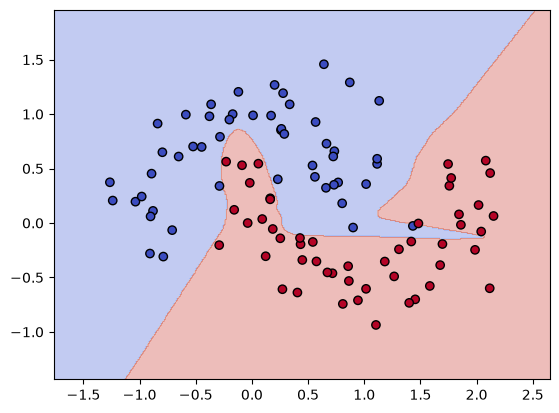

In [9]:
# build prediction grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model1.predict(grid, verbose=0).ravel()
Z = (Z > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

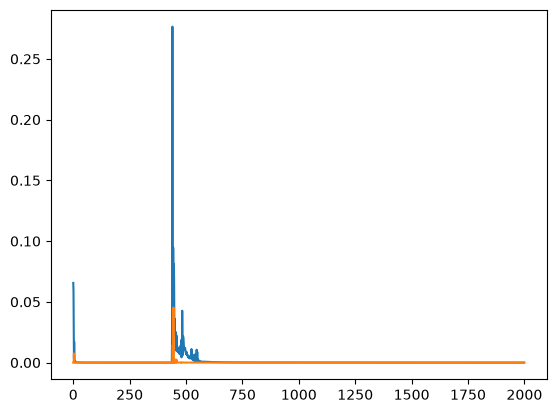

In [10]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [19]:
model1.get_weights()[0].reshape(256).min(), model1.get_weights()[0].reshape(256).max()

(np.float32(-4.931019), np.float32(3.516342))

<Axes: >

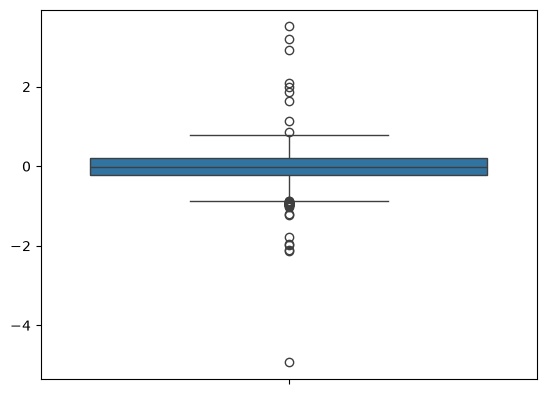

In [25]:
sns.boxplot(model1.get_weights()[0].reshape(256))

# L1 Regularization

In [13]:
model2 = Sequential()

model2.add(Input(shape = (2,)))
model2.add(Dense(128, activation="relu", kernel_regularizer=l1(0.001)))
model2.add(Dense(128, activation="relu", kernel_regularizer=l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

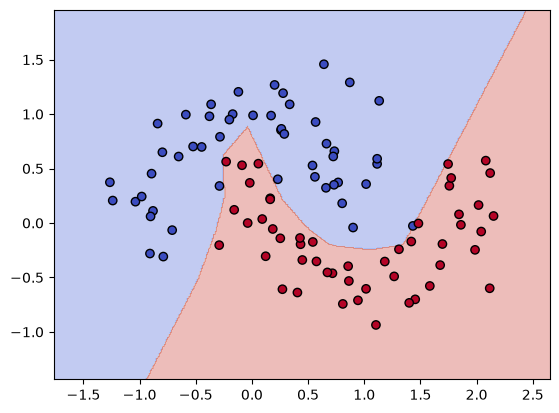

In [15]:
# build prediction grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model2.predict(grid, verbose=0).ravel()
Z = (Z > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

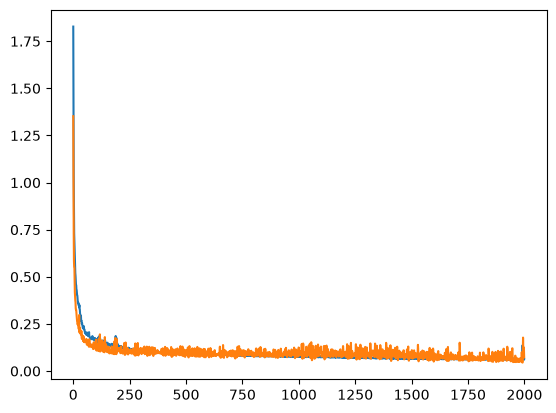

In [16]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [20]:
model2.get_weights()[0].reshape(256).min(), model2.get_weights()[0].reshape(256).max()

(np.float32(-0.21197155), np.float32(0.21478392))

<Axes: >

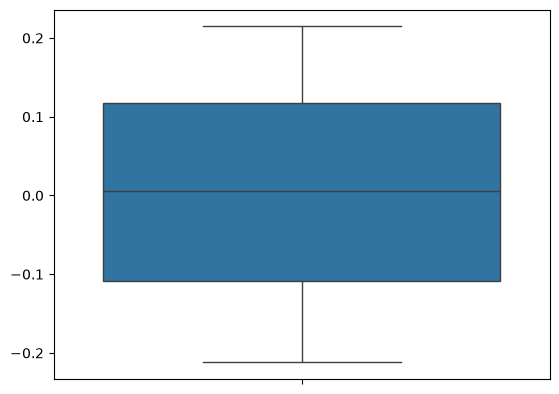

In [28]:
sns.boxplot(model2.get_weights()[0].reshape(256))

# L2 Regularization

In [18]:
model3 = Sequential()

model3.add(Input(shape = (2,)))
model3.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model3.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
adam = Adam(learning_rate=0.01)
model3.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model3.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

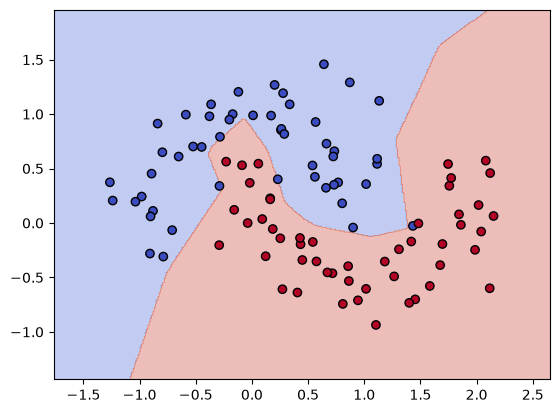

In [22]:
# build prediction grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model3.predict(grid, verbose=0).ravel()
Z = (Z > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

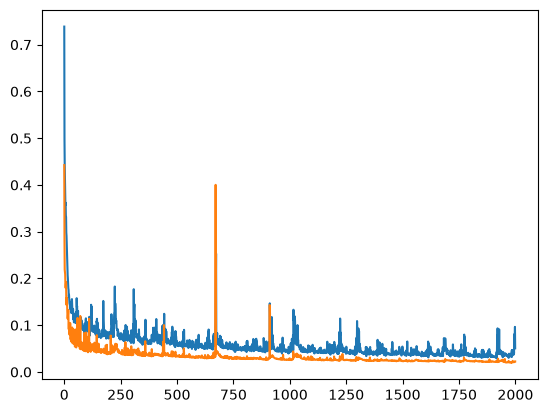

In [23]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [24]:
model3.get_weights()[0].reshape(256).min(), model3.get_weights()[0].reshape(256).max()

(np.float32(-1.5525979), np.float32(0.8184027))

<Axes: >

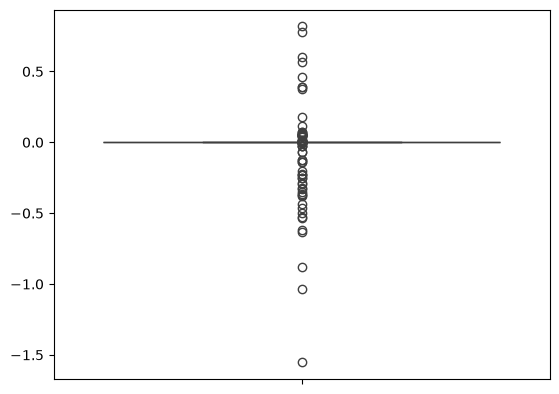

In [27]:
sns.boxplot(model3.get_weights()[0].reshape(256))